<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/external_nonlinear_process_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# External nonlinear process optimization with NeqSim

This long-form notebook connects the Java `ProcessSimulationEvaluator` from current
NeqSim `master` to two external nonlinear optimizers:

- SciPy SLSQP for direct constrained black-box optimization; and
- CasADi with IPOPT through a finite-difference-enabled callback.

The teaching case is a synthetic brownfield rich-gas inlet train with cooling,
condensate separation, export compression, and aftercooling. It is deliberately
small enough for Colab, but it retains the engineering features that make process
optimization difficult: nonlinear phase split, coupled energy demand, several active
capacity limits, solver scaling, infeasible trials, competing objectives, dual values,
and discrete upgrade packages.

**Audience.** Process, production, optimization, and digital-twin engineers; graduate
students; and developers integrating NeqSim with scientific Python.

## Learning objectives

After completing the notebook you can:

1. build an optimization-ready `ProcessSystem` from a synthetic rich gas;
2. define bounded decision variables, objectives, and native constraint margins;
3. scale physical variables for stable numerical optimization;
4. diagnose and restore an infeasible operating point;
5. solve the same nonlinear program with SciPy SLSQP and CasADi/IPOPT;
6. interpret and finite-difference-check shadow prices;
7. trace an epsilon-constraint Pareto front; and
8. enumerate discrete brownfield upgrade packages around a continuous optimizer.


## 1. Scope, assumptions, and safety boundary

The process and economics are public synthetic teaching inputs. Pressures are absolute
(`bara`), temperatures are in degrees Celsius when displayed, mass flow is in `kg/h`,
and duties and shaft powers are in `kW`.

| Item | Teaching assumption |
|---|---|
| Thermodynamics | SRK equation of state with classic mixing rule |
| Feed | Normalized ten-component rich gas at 78 bara and 32 °C |
| Decision variables | Feed rate, inlet-cooler outlet temperature, compressor discharge pressure |
| Hard limits | Driver power, discharge temperature, refrigeration duty, separator gas load, export pressure |
| Refrigeration electricity | Cooler duty divided by an illustrative coefficient of performance of 4 |
| Brownfield economics | Illustrative contribution margin and annualized screening CAPEX only |

This is not a compressor-map, anti-surge, detailed separator-sizing, cost-estimate, or
design-code study. Replace the synthetic limits with verified datasheet, geometry, map,
control, and economic inputs before using the workflow for a real asset.


## 2. Reproducible NeqSim `master` source build

The released Python distribution supplies the JPype bridge. The cell below clones current
`equinor/neqsim` `master`, builds the Java runtime JAR, records the resolved commit and
SHA-256 digest, and verifies that both a main-source probe and
`ProcessSimulationEvaluator` were loaded from that JAR before calculations begin.

A clean local validation may provide `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR` for the
same checked-out commit and built artifact. Google Colab uses the clone-and-build path.


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.16.0",
    "casadi": "3.7.2",
}
install_specs = []
for package_name, required_version in REQUIRED_PACKAGES.items():
    try:
        installed_version = version(package_name)
    except PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        install_specs.append(f"{package_name}=={required_version}")

if install_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *install_specs,
        ],
        check=True,
    )

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

# Record the immutable commit selected from current master (git rev-parse HEAD).
NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import jpype


if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )

jpype.addClassPath(str(SOURCE_JAR))
from neqsim.neqsimpython import init_jvm


init_jvm()
SOURCE_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
EVALUATOR_PROBE = jpype.JClass(
    "neqsim.process.util.optimizer.ProcessSimulationEvaluator"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
EVALUATOR_JAR_LOCATION = str(
    EVALUATOR_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION
assert SOURCE_JAR.name in EVALUATOR_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Loaded evaluator from: {EVALUATOR_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")


NeqSim Python bridge: 3.16.0
NeqSim source ref: master
NeqSim source commit: 1ef241bcdd63c8db2b688c3b275bea1782493bfb
NeqSim source JAR SHA-256: cb568d05857618d96ec953d3da6df1a1c95308a90bbe8211c323b629119f8bd9
Loaded evaluator from: file:/workspace/scratch/ab308ea4a4a5/neqsim/target/neqsim-3.16.0.jar
Python runtime: 3.12.13


In [2]:
from importlib.metadata import version
import math

import casadi as ca
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from neqsim import jneqsim


plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 6)

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Separator = jneqsim.process.equipment.separator.Separator
Compressor = jneqsim.process.equipment.compressor.Compressor
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
ProcessSimulationEvaluator = (
    jneqsim.process.util.optimizer.ProcessSimulationEvaluator
)
ObjectiveDirection = (
    jneqsim.process.util.optimizer.ProcessSimulationEvaluator
    .ObjectiveDefinition.Direction
)

runtime_versions = pd.DataFrame(
    {
        "Package": [
            "neqsim bridge",
            "CasADi",
            "SciPy",
            "NumPy",
            "pandas",
            "Matplotlib",
        ],
        "Version": [
            version("neqsim"),
            version("casadi"),
            version("scipy"),
            version("numpy"),
            version("pandas"),
            version("matplotlib"),
        ],
    }
)
runtime_versions


,Package,Version
0,neqsim bridge,3.16.0
1,CasADi,3.7.2
2,SciPy,1.18.0
3,NumPy,2.5.1
4,pandas,3.0.5
5,Matplotlib,3.11.1


## 3. Nonlinear-program formulation

Let the physical decision vector be
$\mathbf{x}=[\dot m_f,T_c,P_d]^T$: feed rate, inlet-cooler outlet temperature,
and compressor discharge pressure. NeqSim maps each trial to objectives and process
constraints through a full steady-state flash and equipment calculation.

The external solvers receive a dimensionless vector $\mathbf{z}$:

$$\mathbf{z}=\frac{\mathbf{x}-\mathbf{x}^{L}}{\mathbf{x}^{U}-\mathbf{x}^{L}},\qquad 0\leq z_j\leq1$$

The maximum-throughput problem is written as a minimization because both SLSQP and
IPOPT minimize by convention:

$$\begin{aligned}\min_{\mathbf{z}}\quad&-\frac{\dot m_f(\mathbf{z})}{\dot m_{\mathrm{scale}}}\\\mathrm{subject\ to}\quad&\frac{m_i(\mathbf{z})}{s_i}\geq0,\quad i=1,\ldots,n_c\end{aligned}$$

Here $m_i$ is the native NeqSim constraint margin. A positive margin is feasible, zero
is active, and a negative margin is violated. Scaling $s_i$ changes numerical conditioning,
not physical feasibility.

For an active constraint, IPOPT supplies a KKT multiplier $\lambda_i$. With this sign
convention, the local throughput value of relaxing the margin by one physical unit is:

$$\frac{d\dot m_f^*}{d r_i}\approx-\dot m_{\mathrm{scale}}\frac{\lambda_i}{s_i}$$

Shadow prices are local derivatives. They are useful for ranking debottleneck options,
but they are not CAPEX values and can change after the active set changes.


## 4. Process topology

The cooler changes both compression conditions and the amount of condensate removed.
The compressor therefore sees a nonlinear combination of feed rate, temperature,
composition, and phase split.


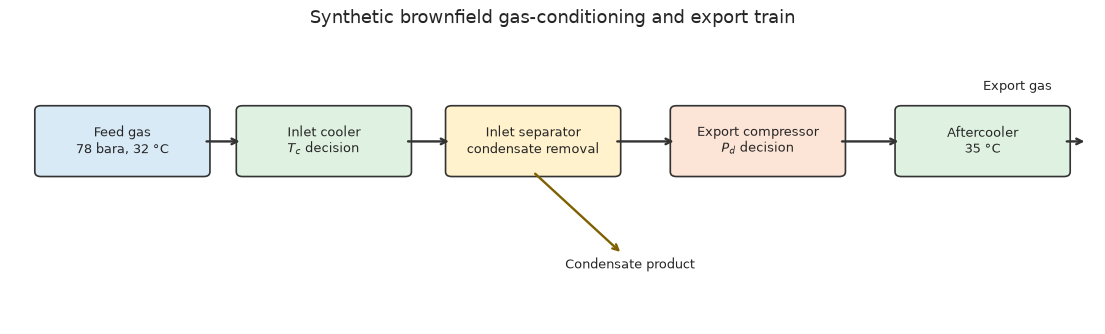

In [3]:
fig, axis = plt.subplots(figsize=(14, 3.8))
axis.set_xlim(0, 14)
axis.set_ylim(0, 5)
axis.axis("off")

equipment_boxes = [
    (0.4, 2.6, "Feed gas\n78 bara, 32 °C", "#D9EAF7"),
    (3.0, 2.6, "Inlet cooler\n$T_c$ decision", "#DFF2E1"),
    (5.7, 2.6, "Inlet separator\ncondensate removal", "#FFF2CC"),
    (8.6, 2.6, "Export compressor\n$P_d$ decision", "#FCE4D6"),
    (11.5, 2.6, "Aftercooler\n35 °C", "#DFF2E1"),
]

for x_position, y_position, label, color in equipment_boxes:
    patch = FancyBboxPatch(
        (x_position, y_position),
        2.1,
        1.05,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="#333333",
        linewidth=1.2,
    )
    axis.add_patch(patch)
    axis.text(
        x_position + 1.05,
        y_position + 0.53,
        label,
        ha="center",
        va="center",
        fontsize=9.5,
    )

for start, end in [(2.5, 3.0), (5.1, 5.7), (7.8, 8.6), (10.7, 11.5)]:
    axis.annotate(
        "",
        xy=(end, 3.12),
        xytext=(start, 3.12),
        arrowprops={"arrowstyle": "->", "lw": 1.7, "color": "#333333"},
    )

axis.annotate(
    "",
    xy=(7.9, 1.2),
    xytext=(6.75, 2.6),
    arrowprops={"arrowstyle": "->", "lw": 1.7, "color": "#7F6000"},
)
axis.text(8.0, 0.95, "Condensate product", ha="center", fontsize=9.5)
axis.annotate(
    "",
    xy=(13.9, 3.12),
    xytext=(13.6, 3.12),
    arrowprops={"arrowstyle": "->", "lw": 1.7, "color": "#333333"},
)
axis.text(13.0, 4.0, "Export gas", ha="center", fontsize=9.5)
axis.set_title("Synthetic brownfield gas-conditioning and export train", fontsize=13)
plt.show()


**Figure discussion — process topology.** Observation: three decisions act upstream of
five constraints, and the separator creates two product paths. Mechanism: cooling changes
the vapor fraction and compression work, while discharge pressure changes the pressure
ratio. Engineering implication: one-variable optimization misses coupled bottlenecks.
Recommendation: keep the complete composable flowsheet inside every evaluator call and
verify both product streams in the mass balance.


## 5. Build and run the NeqSim process

The component amounts are mole-fraction proportions and sum to one. The SRK model and
classic mixing rule are stated explicitly. Multiphase checking remains enabled because
the inlet cooler is intended to condense hydrocarbons.


In [4]:
FEED_COMPOSITION = {
    "nitrogen": 0.010,
    "CO2": 0.020,
    "methane": 0.780,
    "ethane": 0.080,
    "propane": 0.050,
    "i-butane": 0.015,
    "n-butane": 0.020,
    "n-pentane": 0.010,
    "n-hexane": 0.008,
    "n-heptane": 0.007,
}
assert abs(sum(FEED_COMPOSITION.values()) - 1.0) < 1.0e-12


def build_process():
    fluid = SystemSrkEos(273.15 + 32.0, 78.0)
    for component_name, mole_fraction in FEED_COMPOSITION.items():
        fluid.addComponent(component_name, mole_fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)

    feed = Stream("Feed Gas", fluid)
    feed.setFlowRate(100_000.0, "kg/hr")
    feed.setTemperature(32.0, "C")
    feed.setPressure(78.0, "bara")

    inlet_cooler = Cooler("Inlet Cooler", feed)
    inlet_cooler.setOutletTemperature(18.0, "C")

    separator = Separator("Inlet Separator", inlet_cooler.getOutletStream())
    separator.setOrientation("vertical")
    separator.setInternalDiameter(3.0)

    compressor = Compressor(
        "Export Compressor",
        separator.getGasOutStream(),
    )
    compressor.setOutletPressure(128.0, "bara")
    compressor.setPolytropicEfficiency(0.78)
    compressor.setUsePolytropicCalc(True)

    aftercooler = Cooler(
        "Export Aftercooler",
        compressor.getOutletStream(),
    )
    aftercooler.setOutletTemperature(35.0, "C")

    export_gas = Stream("Export Gas", aftercooler.getOutletStream())
    condensate = Stream("Condensate", separator.getLiquidOutStream())

    process = ProcessSystem()
    process_units = [
        feed,
        inlet_cooler,
        separator,
        compressor,
        aftercooler,
        export_gas,
        condensate,
    ]
    for process_unit in process_units:
        process.add(process_unit)
    process.run()
    return process


process = build_process()


In [5]:
feed = process.getUnit("Feed Gas")
inlet_cooler = process.getUnit("Inlet Cooler")
separator = process.getUnit("Inlet Separator")
compressor = process.getUnit("Export Compressor")
aftercooler = process.getUnit("Export Aftercooler")
export_gas = process.getUnit("Export Gas")
condensate = process.getUnit("Condensate")

feed_mass_kg_per_h = feed.getFlowRate("kg/hr")
product_mass_kg_per_h = (
    export_gas.getFlowRate("kg/hr")
    + condensate.getFlowRate("kg/hr")
)
relative_mass_residual = abs(
    feed_mass_kg_per_h - product_mass_kg_per_h
) / feed_mass_kg_per_h

base_results = pd.DataFrame(
    {
        "Quantity": [
            "Feed mass flow",
            "Export-gas mass flow",
            "Condensate mass flow",
            "Compressor power",
            "Compressor discharge temperature",
            "Inlet-cooler duty magnitude",
            "Separator gas-load factor",
            "Relative mass residual",
        ],
        "Value": [
            feed_mass_kg_per_h,
            export_gas.getFlowRate("kg/hr"),
            condensate.getFlowRate("kg/hr"),
            compressor.getPower("kW"),
            compressor.getOutletStream().getTemperature("C"),
            abs(inlet_cooler.getDuty("kW")),
            separator.getGasLoadFactor(),
            relative_mass_residual,
        ],
        "Unit": [
            "kg/h",
            "kg/h",
            "kg/h",
            "kW",
            "°C",
            "kW",
            "m/s",
            "fraction",
        ],
    }
)

assert relative_mass_residual < 1.0e-8
base_results


,Quantity,Value,Unit
0,Feed mass flow,1.000000e+05,kg/h
1,Export-gas mass flow,8.404072e+04,kg/h
2,Condensate mass flow,1.595928e+04,kg/h
3,Compressor power,1.498677e+03,kW
4,Compressor discharge temperature,5.802092e+01,°C
5,Inlet-cooler duty magnitude,1.353748e+03,kW
6,Separator gas-load factor,1.756230e-02,m/s
7,Relative mass residual,1.455192e-16,fraction


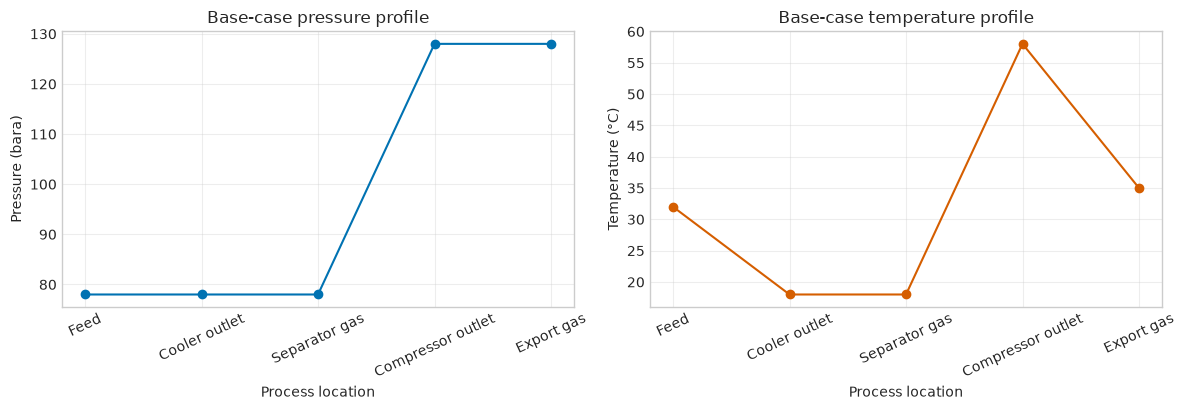

In [6]:
profile_names = [
    "Feed",
    "Cooler outlet",
    "Separator gas",
    "Compressor outlet",
    "Export gas",
]
profile_streams = [
    feed,
    inlet_cooler.getOutletStream(),
    separator.getGasOutStream(),
    compressor.getOutletStream(),
    export_gas,
]
pressure_profile = [
    stream.getPressure("bara")
    for stream in profile_streams
]
temperature_profile = [
    stream.getTemperature("C")
    for stream in profile_streams
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(profile_names, pressure_profile, "o-", color="#0072B2")
axes[0].set_ylabel("Pressure (bara)")
axes[0].set_title("Base-case pressure profile")
axes[0].tick_params(axis="x", rotation=25)

axes[1].plot(profile_names, temperature_profile, "o-", color="#D55E00")
axes[1].set_ylabel("Temperature (°C)")
axes[1].set_title("Base-case temperature profile")
axes[1].tick_params(axis="x", rotation=25)

for profile_axis in axes:
    profile_axis.set_xlabel("Process location")
    profile_axis.grid(True, alpha=0.35)

fig.tight_layout()
plt.show()


**Figure discussion — base profiles.** Observation: the inlet cooler reduces the stream
from 32 to 18 °C at essentially constant pressure; the compressor raises pressure from
78 to 128 bara and temperature to about 58 °C; the aftercooler returns the gas to 35 °C.
Mechanism: condensation occurs before separation, and compression converts shaft work to
gas enthalpy. Engineering implication: cooling and pressure-ratio decisions affect both
phase split and power. Recommendation: preserve these pressure and temperature orderings
as validation checks in every optimized case.


## 6. Configure `ProcessSimulationEvaluator`

`cloneForEvaluation=True` makes each trial start from an independent process copy. This is
slower than mutating one live flowsheet, but it prevents trial order and failed candidates
from contaminating subsequent results. All external solvers use the same evaluator,
decision bounds, objective definitions, and constraint registration order.


In [7]:
DRIVER_LIMIT_KW = 2_600.0
DISCHARGE_TEMPERATURE_LIMIT_C = 120.0
INLET_COOLER_LIMIT_KW = 3_500.0
SEPARATOR_GAS_LOAD_LIMIT_M_PER_S = 0.033
MINIMUM_EXPORT_PRESSURE_BARA = 122.0
COOLING_COP = 4.0


def total_electric_equivalent_power(candidate_process):
    candidate_compressor = candidate_process.getUnit("Export Compressor")
    candidate_cooler = candidate_process.getUnit("Inlet Cooler")
    compressor_power = candidate_compressor.getPower("kW")
    refrigeration_power = abs(candidate_cooler.getDuty("kW")) / COOLING_COP
    return compressor_power + refrigeration_power


def candidate_mass_residual(candidate_process):
    candidate_feed = candidate_process.getUnit("Feed Gas")
    candidate_gas = candidate_process.getUnit("Export Gas")
    candidate_liquid = candidate_process.getUnit("Condensate")
    mass_in = candidate_feed.getFlowRate("kg/hr")
    mass_out = (
        candidate_gas.getFlowRate("kg/hr")
        + candidate_liquid.getFlowRate("kg/hr")
    )
    return abs(mass_in - mass_out) / mass_in


evaluator = ProcessSimulationEvaluator(process)
evaluator.setCloneForEvaluation(True)
evaluator.addParameter(
    "Feed Gas",
    "flowRate",
    50_000.0,
    240_000.0,
    "kg/hr",
)
evaluator.addParameter(
    "Inlet Cooler",
    "outletTemperature",
    5.0,
    30.0,
    "C",
)
evaluator.addParameter(
    "Export Compressor",
    "outletPressure",
    115.0,
    140.0,
    "bara",
)

evaluator.addObjective(
    "feed_throughput_kg_per_h",
    lambda candidate: candidate.getUnit("Feed Gas").getFlowRate("kg/hr"),
    ObjectiveDirection.MAXIMIZE,
)
evaluator.addObjective(
    "electric_equivalent_power_kW",
    total_electric_equivalent_power,
    ObjectiveDirection.MINIMIZE,
)
evaluator.addObjective(
    "relative_mass_residual",
    candidate_mass_residual,
    ObjectiveDirection.MINIMIZE,
)

evaluator.addConstraintUpperBound(
    "driver_power",
    lambda candidate: candidate.getUnit("Export Compressor").getPower("kW"),
    DRIVER_LIMIT_KW,
)
evaluator.addConstraintUpperBound(
    "discharge_temperature",
    lambda candidate: candidate.getUnit("Export Compressor")
    .getOutletStream()
    .getTemperature("C"),
    DISCHARGE_TEMPERATURE_LIMIT_C,
)
evaluator.addConstraintUpperBound(
    "inlet_cooler_duty",
    lambda candidate: abs(
        candidate.getUnit("Inlet Cooler").getDuty("kW")
    ),
    INLET_COOLER_LIMIT_KW,
)
evaluator.addConstraintUpperBound(
    "separator_gas_load",
    lambda candidate: candidate.getUnit(
        "Inlet Separator"
    ).getGasLoadFactor(),
    SEPARATOR_GAS_LOAD_LIMIT_M_PER_S,
)
evaluator.addConstraintLowerBound(
    "export_pressure",
    lambda candidate: candidate.getUnit("Export Gas").getPressure("bara"),
    MINIMUM_EXPORT_PRESSURE_BARA,
)

constraint_metadata = [
    {
        "name": "Driver power",
        "sense": "≤",
        "limit": DRIVER_LIMIT_KW,
        "unit": "kW",
    },
    {
        "name": "Discharge temperature",
        "sense": "≤",
        "limit": DISCHARGE_TEMPERATURE_LIMIT_C,
        "unit": "°C",
    },
    {
        "name": "Inlet-cooler duty",
        "sense": "≤",
        "limit": INLET_COOLER_LIMIT_KW,
        "unit": "kW",
    },
    {
        "name": "Separator gas load",
        "sense": "≤",
        "limit": SEPARATOR_GAS_LOAD_LIMIT_M_PER_S,
        "unit": "m/s",
    },
    {
        "name": "Export pressure",
        "sense": "≥",
        "limit": MINIMUM_EXPORT_PRESSURE_BARA,
        "unit": "bara",
    },
]

for constraint, metadata in zip(
    list(evaluator.getConstraints()),
    constraint_metadata,
):
    constraint.setUnit(metadata["unit"])

print(evaluator.toJson())


{
  "parameters": [
    {"name": "Feed Gas.flowRate", "bounds": [50000.0, 240000.0], "unit": "kg/hr"},
    {"name": "Inlet Cooler.outletTemperature", "bounds": [5.0, 30.0], "unit": "C"},
    {"name": "Export Compressor.outletPressure", "bounds": [115.0, 140.0], "unit": "bara"}
  ],
  "objectives": [
    {"name": "feed_throughput_kg_per_h", "direction": "MAXIMIZE"},
    {"name": "electric_equivalent_power_kW", "direction": "MINIMIZE"},
    {"name": "relative_mass_residual", "direction": "MINIMIZE"}
  ],
  "constraints": [
    {"name": "driver_power", "type": "UPPER_BOUND"},
    {"name": "discharge_temperature", "type": "UPPER_BOUND"},
    {"name": "inlet_cooler_duty", "type": "UPPER_BOUND"},
    {"name": "separator_gas_load", "type": "UPPER_BOUND"},
    {"name": "export_pressure", "type": "LOWER_BOUND"}
  ]
}


In [8]:
parameter_rows = []
for parameter in list(evaluator.getParameters()):
    parameter_rows.append(
        {
            "Decision variable": str(parameter.getName()),
            "Lower bound": parameter.getLowerBound(),
            "Initial value": parameter.getInitialValue(),
            "Upper bound": parameter.getUpperBound(),
            "Unit": str(parameter.getUnit()),
        }
    )

constraint_rows = []
for metadata in constraint_metadata:
    constraint_rows.append(
        {
            "Constraint": metadata["name"],
            "Requirement": (
                f"value {metadata['sense']} {metadata['limit']:g}"
            ),
            "Unit": metadata["unit"],
            "Feasible margin sign": "positive",
        }
    )

display(pd.DataFrame(parameter_rows))
display(pd.DataFrame(constraint_rows))


,Decision variable,Lower bound,Initial value,Upper bound,Unit
0,Feed Gas.flowRate,50000.0,145000.0,240000.0,kg/hr
1,Inlet Cooler.outletTemperature,5.0,17.5,30.0,C
2,Export Compressor.outletPressure,115.0,127.5,140.0,bara


,Constraint,Requirement,Unit,Feasible margin sign
0,Driver power,value ≤ 2600,kW,positive
1,Discharge temperature,value ≤ 120,°C,positive
2,Inlet-cooler duty,value ≤ 3500,kW,positive
3,Separator gas load,value ≤ 0.033,m/s,positive
4,Export pressure,value ≥ 122,bara,positive


### Evaluator result contract

For every trial, `EvaluationResult` stores the physical parameters, sign-adjusted and raw
objectives, constraint values, margin vector, feasibility flag, penalty sum, convergence
flag, error message, evaluation time, and evaluation number. A maximizing objective is
sign-adjusted internally so its minimized value is negative; always use
`getObjectivesRaw()` for engineering reporting.


In [9]:
def constraint_diagnostics(evaluation_result):
    values = np.asarray(
        evaluation_result.getConstraintValues(),
        dtype=float,
    )
    margins = np.asarray(
        evaluation_result.getConstraintMargins(),
        dtype=float,
    )
    rows = []
    for index, metadata in enumerate(constraint_metadata):
        scale = max(abs(metadata["limit"]), 1.0e-12)
        normalized_margin = margins[index] / scale
        if normalized_margin < -2.0e-4:
            status = "VIOLATED"
        elif abs(normalized_margin) <= 2.0e-4:
            status = "AT LIMIT"
        else:
            status = "OK"
        rows.append(
            {
                "Constraint": metadata["name"],
                "Value": values[index],
                "Requirement": (
                    f"{metadata['sense']} {metadata['limit']:g}"
                ),
                "Margin": margins[index],
                "Normalized margin": normalized_margin,
                "Unit": metadata["unit"],
                "Status": status,
            }
        )
    return pd.DataFrame(rows)


teaching_points = {
    "Base": np.array([100_000.0, 18.0, 128.0]),
    "High, cold, high pressure": np.array([240_000.0, 5.0, 140.0]),
    "High, warm, minimum pressure": np.array([240_000.0, 30.0, 122.0]),
    "Intermediate": np.array([150_000.0, 18.0, 128.0]),
}

point_rows = []
point_results = {}
for point_name, physical_point in teaching_points.items():
    evaluation_result = evaluator.evaluate(physical_point)
    point_results[point_name] = evaluation_result
    raw_objectives = np.asarray(
        evaluation_result.getObjectivesRaw(),
        dtype=float,
    )
    margins = np.asarray(
        evaluation_result.getConstraintMargins(),
        dtype=float,
    )
    point_rows.append(
        {
            "Case": point_name,
            "Feed (kg/h)": physical_point[0],
            "Cooler outlet (°C)": physical_point[1],
            "Discharge (bara)": physical_point[2],
            "Electric equivalent (kW)": raw_objectives[1],
            "Minimum margin": margins.min(),
            "Evaluator feasible": evaluation_result.isFeasible(),
            "Simulation converged": (
                evaluation_result.isSimulationConverged()
            ),
        }
    )

pd.DataFrame(point_rows)


,Case,Feed (kg/h),Cooler outlet (°C),Discharge (bara),Electric equivalent (kW),Minimum margin,Evaluator feasible,Simulation converged
0,Base,100000.0,18.0,128.0,1837.113921,0.015438,True,True
1,"High, cold, high pressure",240000.0,5.0,140.0,5448.792091,-2897.729099,False,True
2,"High, warm, minimum pressure",240000.0,30.0,122.0,3646.937135,-932.779340,False,True
3,Intermediate,150000.0,18.0,128.0,2755.670881,0.006657,True,True


In [10]:
high_case_diagnostics = constraint_diagnostics(
    point_results["High, cold, high pressure"]
)
high_case_diagnostics


,Constraint,Value,Requirement,Margin,Normalized margin,Unit,Status
0,Driver power,3849.359816,≤ 2600,-1249.359816,-0.480523,kW,VIOLATED
1,Discharge temperature,51.139704,≤ 120,68.860296,0.573836,°C,OK
2,Inlet-cooler duty,6397.729099,≤ 3500,-2897.729099,-0.827923,kW,VIOLATED
3,Separator gas load,0.038861,≤ 0.033,-0.005861,-0.177611,m/s,VIOLATED
4,Export pressure,140.000000,≥ 122,18.000000,0.147541,bara,OK


The raw high-flow trial violates several constraints at once. The margin vector identifies
the direction and magnitude without requiring exception parsing. This is the key bridge
contract: external optimizers consume the same ordered $m_i(\mathbf{x})\geq0$ vector,
while engineers retain named physical diagnostics.


## 7. Native finite-difference derivatives

`ProcessSimulationEvaluator` can estimate the primary-objective gradient and the complete
constraint-margin Jacobian in physical coordinates. The direct external solvers below use
dimensionless coordinates, but the native derivatives remain valuable for sensitivity
inspection and adapter development.


In [11]:
base_point = teaching_points["Base"]
native_gradient = np.asarray(
    evaluator.estimateGradient(base_point),
    dtype=float,
)
native_constraint_jacobian = np.asarray(
    evaluator.estimateConstraintJacobian(base_point),
    dtype=float,
)

derivative_columns = [
    "Feed rate (kg/h)",
    "Cooler outlet (°C)",
    "Discharge pressure (bara)",
]
gradient_table = pd.DataFrame(
    [native_gradient],
    index=["Signed throughput objective"],
    columns=derivative_columns,
)
jacobian_table = pd.DataFrame(
    native_constraint_jacobian,
    index=[item["name"] for item in constraint_metadata],
    columns=derivative_columns,
)

display(gradient_table)
display(jacobian_table)


,Feed rate (kg/h),Cooler outlet (°C),Discharge pressure (bara)
Signed throughput objective,-1.0,0.0,0.0


,Feed rate (kg/h),Cooler outlet (°C),Discharge pressure (bara)
Driver power,-1.498677e-02,-12.638162,-26.253946
Discharge temperature,-1.705303e-14,-1.074298,-0.648466
Inlet-cooler duty,-1.353748e-02,507837.344805,0.000000
Separator gas load,-1.756230e-07,-0.000101,0.000000
Export pressure,0.000000e+00,0.000000,1.000000


## 8. A reusable scaled SciPy adapter

Large mass-flow numbers and small gas-load factors differ by more than six orders of
magnitude. The adapter maps all three decisions to $[0,1]$, normalizes each margin by a
representative physical scale, and caches duplicate objective/constraint requests at the
same point. The evaluator remains the sole source of process physics.


In [12]:
physical_bounds = np.asarray(evaluator.getBounds(), dtype=float)
lower_bounds = physical_bounds[:, 0]
upper_bounds = physical_bounds[:, 1]
variable_ranges = upper_bounds - lower_bounds

THROUGHPUT_SCALE_KG_PER_H = 100_000.0
ENERGY_SCALE_KW = 3_000.0
constraint_scales = np.array(
    [
        DRIVER_LIMIT_KW,
        DISCHARGE_TEMPERATURE_LIMIT_C,
        INLET_COOLER_LIMIT_KW,
        SEPARATOR_GAS_LOAD_LIMIT_M_PER_S,
        MINIMUM_EXPORT_PRESSURE_BARA,
    ]
)
evaluation_cache = {}


def to_scaled(physical_point):
    point = np.asarray(physical_point, dtype=float)
    return (point - lower_bounds) / variable_ranges


def to_physical(scaled_point):
    point = np.asarray(scaled_point, dtype=float)
    return lower_bounds + point * variable_ranges


def clear_evaluation_cache():
    evaluation_cache.clear()


def evaluate_scaled(scaled_point):
    physical_point = to_physical(scaled_point)
    cache_key = tuple(np.round(physical_point, 7))
    if cache_key not in evaluation_cache:
        evaluation_cache[cache_key] = evaluator.evaluate(physical_point)
    return evaluation_cache[cache_key]


def throughput_objective(scaled_point):
    evaluation_result = evaluate_scaled(scaled_point)
    signed_objective = float(evaluation_result.getObjectives()[0])
    return signed_objective / THROUGHPUT_SCALE_KG_PER_H


def energy_objective(scaled_point):
    evaluation_result = evaluate_scaled(scaled_point)
    signed_objective = float(evaluation_result.getObjectives()[1])
    return signed_objective / ENERGY_SCALE_KW


def native_margin_vector(scaled_point):
    evaluation_result = evaluate_scaled(scaled_point)
    margins = np.asarray(
        evaluation_result.getConstraintMargins(),
        dtype=float,
    )
    return margins / constraint_scales


def solve_slsqp(
    initial_physical_point,
    objective_callback=throughput_objective,
    extra_constraints=None,
):
    constraints = [{"type": "ineq", "fun": native_margin_vector}]
    if extra_constraints:
        for extra_constraint in extra_constraints:
            if callable(extra_constraint):
                constraints.append(
                    {"type": "ineq", "fun": extra_constraint}
                )
            else:
                constraints.append(extra_constraint)
    return minimize(
        objective_callback,
        x0=to_scaled(initial_physical_point),
        method="SLSQP",
        bounds=[(0.0, 1.0)] * evaluator.getParameterCount(),
        constraints=constraints,
        options={
            "ftol": 1.0e-7,
            "maxiter": 100,
            "disp": False,
        },
    )


## 9. Infeasibility diagnosis and feasibility restoration

An optimizer needs a response when a requested point cannot satisfy the plant limits. A
diagnostic report ranks negative margins. A separate restoration problem then minimizes
dimensionless distance from the requested point subject to all native margins. This does
not optimize economics; it finds a nearby feasible operating point for operator feedback
or for initializing a more demanding NLP.


In [13]:
requested_physical_point = np.array([240_000.0, 5.0, 140.0])
requested_scaled_point = to_scaled(requested_physical_point)


def distance_to_request(scaled_point):
    delta = np.asarray(scaled_point) - requested_scaled_point
    return float(delta @ delta)


clear_evaluation_cache()
restoration_solution = minimize(
    distance_to_request,
    x0=to_scaled(base_point),
    method="SLSQP",
    bounds=[(0.0, 1.0)] * evaluator.getParameterCount(),
    constraints={"type": "ineq", "fun": native_margin_vector},
    options={"ftol": 1.0e-8, "maxiter": 120, "disp": False},
)
restored_physical_point = to_physical(restoration_solution.x)
requested_result = evaluator.evaluate(requested_physical_point)
restored_result = evaluator.evaluate(restored_physical_point)

restoration_summary = pd.DataFrame(
    {
        "Variable": [
            "Feed rate (kg/h)",
            "Cooler outlet (°C)",
            "Discharge pressure (bara)",
        ],
        "Requested": requested_physical_point,
        "Nearest feasible": restored_physical_point,
        "Change": restored_physical_point - requested_physical_point,
    }
)

assert restoration_solution.success
display(restoration_summary)
display(constraint_diagnostics(restored_result))


,Variable,Requested,Nearest feasible,Change
0,Feed rate (kg/h),240000.0,158246.777010,-81753.222990
1,Cooler outlet (°C),5.0,9.430478,4.430478
2,Discharge pressure (bara),140.0,138.656257,-1.343743


,Constraint,Value,Requirement,Margin,Normalized margin,Unit,Status
0,Driver power,2600.000000,≤ 2600,4.365447e-07,1.679018e-10,kW,AT LIMIT
1,Discharge temperature,55.292200,≤ 120,6.470780e+01,5.392317e-01,°C,OK
2,Inlet-cooler duty,3500.000005,≤ 3500,-5.185609e-06,-1.481602e-09,kW,AT LIMIT
3,Separator gas load,0.026383,≤ 0.033,6.617171e-03,2.005203e-01,m/s,OK
4,Export pressure,138.656257,≥ 122,1.665626e+01,1.365267e-01,bara,OK


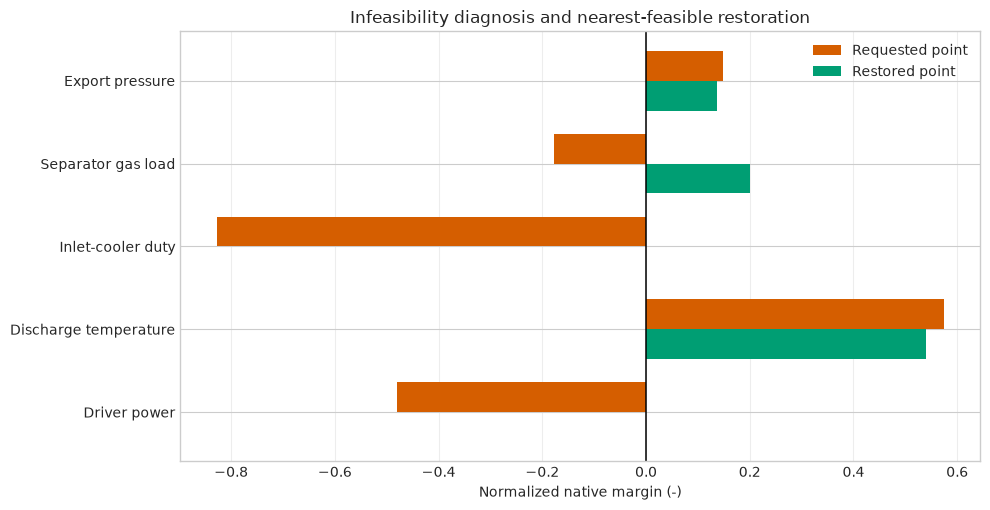

In [14]:
requested_margins = np.asarray(
    requested_result.getConstraintMargins(),
    dtype=float,
) / constraint_scales
restored_margins = np.asarray(
    restored_result.getConstraintMargins(),
    dtype=float,
) / constraint_scales
constraint_labels = [item["name"] for item in constraint_metadata]
bar_positions = np.arange(len(constraint_labels))
bar_height = 0.36

fig, axis = plt.subplots(figsize=(10, 5.2))
axis.barh(
    bar_positions + bar_height / 2,
    requested_margins,
    height=bar_height,
    color="#D55E00",
    label="Requested point",
)
axis.barh(
    bar_positions - bar_height / 2,
    restored_margins,
    height=bar_height,
    color="#009E73",
    label="Restored point",
)
axis.axvline(0.0, color="black", linewidth=1.1)
axis.set_yticks(bar_positions, constraint_labels)
axis.set_xlabel("Normalized native margin (-)")
axis.set_title("Infeasibility diagnosis and nearest-feasible restoration")
axis.legend()
axis.grid(True, axis="x", alpha=0.35)
fig.tight_layout()
plt.show()


**Figure discussion — infeasibility.** Observation: the requested 240 t/h point has
negative driver, refrigeration, and separator margins; restoration moves every bar to
zero or positive. Mechanism: rate, cooling, and pressure ratio jointly consume installed
capacity. Engineering implication: a single generic penalty hides which equipment blocks
the request. Recommendation: return named physical margins and a restored point to the
decision maker before discussing an upgrade.


## 10. Direct constrained optimization with SciPy SLSQP

The same maximum-throughput problem is solved from three distinct starts. Multistart does
not prove a global optimum, but agreement is stronger evidence than a single local solve.
All function and constraint calls pass through `ProcessSimulationEvaluator`.


In [15]:
slsqp_starts = {
    "Base start": np.array([100_000.0, 18.0, 128.0]),
    "Low-rate warm start": np.array([70_000.0, 27.0, 122.0]),
    "High-rate cold start": np.array([180_000.0, 10.0, 125.0]),
}

slsqp_records = []
slsqp_solutions = {}
for start_name, start_point in slsqp_starts.items():
    clear_evaluation_cache()
    solution = solve_slsqp(start_point)
    physical_solution = to_physical(solution.x)
    exact_result = evaluator.evaluate(physical_solution)
    raw_objectives = np.asarray(
        exact_result.getObjectivesRaw(),
        dtype=float,
    )
    normalized_margins = np.asarray(
        exact_result.getConstraintMargins(),
        dtype=float,
    ) / constraint_scales
    slsqp_solutions[start_name] = (
        solution,
        physical_solution,
        exact_result,
    )
    slsqp_records.append(
        {
            "Start": start_name,
            "Success": solution.success,
            "Iterations": solution.nit,
            "Evaluations": solution.nfev,
            "Feed (kg/h)": raw_objectives[0],
            "Cooler outlet (°C)": physical_solution[1],
            "Discharge (bara)": physical_solution[2],
            "Electric equivalent (kW)": raw_objectives[1],
            "Minimum normalized margin": normalized_margins.min(),
            "Mass residual": raw_objectives[2],
        }
    )

slsqp_summary = pd.DataFrame(slsqp_records)
successful_rows = slsqp_summary[slsqp_summary["Success"]]
assert len(successful_rows) == len(slsqp_starts)
best_start_name = successful_rows.sort_values(
    "Feed (kg/h)",
    ascending=False,
).iloc[0]["Start"]
slsqp_solution, scipy_physical_point, scipy_exact_result = (
    slsqp_solutions[best_start_name]
)
slsqp_summary


,Start,Success,Iterations,Evaluations,Feed (kg/h),Cooler outlet (°C),Discharge (bara),Electric equivalent (kW),Minimum normalized margin,Mass residual
0,Base start,True,6,34,193101.224149,13.393178,124.335235,3474.684923,1.000252e-12,1.507180e-16
1,Low-rate warm start,True,7,29,193108.126832,13.387311,122.000000,3358.577267,-5.105247e-08,1.507126e-16
2,High-rate cold start,True,10,51,192963.709190,13.510257,124.222309,3463.688532,1.827806e-10,0.000000e+00


In [16]:
scipy_optimum_diagnostics = constraint_diagnostics(scipy_exact_result)
scipy_optimum_diagnostics


,Constraint,Value,Requirement,Margin,Normalized margin,Unit,Status
0,Driver power,2483.577222,≤ 2600,1.164228e+02,4.477799e-02,kW,OK
1,Discharge temperature,49.102428,≤ 120,7.089757e+01,5.908131e-01,°C,OK
2,Inlet-cooler duty,3500.000179,≤ 3500,-1.786836e-04,-5.105247e-08,kW,AT LIMIT
3,Separator gas load,0.033000,≤ 0.033,-5.976388e-10,-1.811027e-08,m/s,AT LIMIT
4,Export pressure,122.000000,≥ 122,0.000000e+00,0.000000e+00,bara,AT LIMIT


The optimization is considered feasible when every normalized margin is above a small
solver tolerance. `EvaluationResult.isFeasible()` uses an exact zero threshold, so a point
that is only a few floating-point units below zero can be reported as false even though it
satisfies the NLP tolerance. The engineering table retains the unrounded margins so this
distinction remains visible.


## 11. CasADi callback and IPOPT

CasADi cannot symbolically differentiate the Java thermodynamic model. Its `Callback`
interface therefore calls the exact NeqSim evaluator and enables finite differences.
IPOPT uses a limited-memory Hessian approximation; without it, second derivatives of a
black-box flash model are unnecessarily expensive and more sensitive to numerical noise.


In [17]:
class NeqSimNlpCallback(ca.Callback):
    def __init__(self, name):
        ca.Callback.__init__(self)
        self.construct(name, {"enable_fd": True})

    def get_n_in(self):
        return 1

    def get_n_out(self):
        return 1

    def get_sparsity_in(self, index):
        return ca.Sparsity.dense(evaluator.getParameterCount(), 1)

    def get_sparsity_out(self, index):
        output_count = 1 + evaluator.getConstraintCount()
        return ca.Sparsity.dense(output_count, 1)

    def eval(self, arguments):
        scaled_point = np.asarray(
            arguments[0],
            dtype=float,
        ).reshape(-1)
        evaluation_result = evaluate_scaled(scaled_point)
        objective_value = (
            float(evaluation_result.getObjectives()[0])
            / THROUGHPUT_SCALE_KG_PER_H
        )
        margins = np.asarray(
            evaluation_result.getConstraintMargins(),
            dtype=float,
        ) / constraint_scales
        combined_output = np.concatenate([[objective_value], margins])
        return [ca.DM(combined_output)]


clear_evaluation_cache()
neqsim_callback = NeqSimNlpCallback("neqsim_external_process")
scaled_symbol = ca.MX.sym("scaled_decisions", evaluator.getParameterCount())
callback_output = neqsim_callback(scaled_symbol)
nonlinear_program = {
    "x": scaled_symbol,
    "f": callback_output[0],
    "g": callback_output[1:],
}

ipopt_solver = ca.nlpsol(
    "neqsim_ipopt_solver",
    "ipopt",
    nonlinear_program,
    {
        "ipopt.print_level": 0,
        "ipopt.sb": "yes",
        "ipopt.max_iter": 80,
        "ipopt.tol": 1.0e-7,
        "ipopt.acceptable_tol": 1.0e-5,
        "ipopt.hessian_approximation": "limited-memory",
        "print_time": False,
    },
)

ipopt_solution = ipopt_solver(
    x0=to_scaled(scipy_physical_point),
    lbx=np.zeros(evaluator.getParameterCount()),
    ubx=np.ones(evaluator.getParameterCount()),
    lbg=np.zeros(evaluator.getConstraintCount()),
    ubg=np.full(evaluator.getConstraintCount(), np.inf),
)
ipopt_scaled_point = np.asarray(
    ipopt_solution["x"],
    dtype=float,
).reshape(-1)
ipopt_physical_point = to_physical(ipopt_scaled_point)
ipopt_exact_result = evaluator.evaluate(ipopt_physical_point)
ipopt_stats = ipopt_solver.stats()

assert ipopt_stats["success"]

solver_comparison = pd.DataFrame(
    {
        "Quantity": [
            "Return status",
            "Feed rate (kg/h)",
            "Cooler outlet (°C)",
            "Discharge pressure (bara)",
            "Minimum normalized margin",
            "Relative mass residual",
        ],
        "SciPy SLSQP": [
            slsqp_solution.message,
            scipy_exact_result.getObjectivesRaw()[0],
            scipy_physical_point[1],
            scipy_physical_point[2],
            (
                np.asarray(
                    scipy_exact_result.getConstraintMargins(),
                    dtype=float,
                )
                / constraint_scales
            ).min(),
            scipy_exact_result.getObjectivesRaw()[2],
        ],
        "CasADi/IPOPT": [
            ipopt_stats["return_status"],
            ipopt_exact_result.getObjectivesRaw()[0],
            ipopt_physical_point[1],
            ipopt_physical_point[2],
            (
                np.asarray(
                    ipopt_exact_result.getConstraintMargins(),
                    dtype=float,
                )
                / constraint_scales
            ).min(),
            ipopt_exact_result.getObjectivesRaw()[2],
        ],
    }
)
solver_comparison


,Quantity,SciPy SLSQP,CasADi/IPOPT
0,Return status,Optimization terminated successfully,Solve_Succeeded
1,Feed rate (kg/h),193108.126832,193108.124633
2,Cooler outlet (°C),13.387311,13.387312
3,Discharge pressure (bara),122.0,122.532712
4,Minimum normalized margin,-0.0,-0.0
5,Relative mass residual,0.0,0.0


In [18]:
constraint_diagnostics(ipopt_exact_result)


,Constraint,Value,Requirement,Margin,Normalized margin,Unit,Status
0,Driver power,2510.230157,≤ 2600,8.976984e+01,3.452686e-02,kW,OK
1,Discharge temperature,49.459186,≤ 120,7.054081e+01,5.878401e-01,°C,OK
2,Inlet-cooler duty,3500.000035,≤ 3500,-3.482932e-05,-9.951234e-09,kW,AT LIMIT
3,Separator gas load,0.033000,≤ 0.033,-3.298236e-10,-9.994654e-09,m/s,AT LIMIT
4,Export pressure,122.532712,≥ 122,5.327121e-01,4.366492e-03,bara,OK


Both solvers find essentially the same capacity neighborhood, but the decision variables
need not match exactly because several constraints are nearly active and the problem has a
shallow local ridge. Solver agreement should therefore be checked on engineering outputs,
constraint margins, and nearby-point behavior—not only on identical decision vectors.


## 12. Shadow prices and finite-difference verification

The IPOPT multipliers are converted to local throughput gains for a positive relaxation
of each physical margin. Inactive constraints are reported as zero. Two active constraints
are then relaxed explicitly and the NLP is re-solved to verify the dual prediction.


In [19]:
ipopt_multipliers = np.asarray(
    ipopt_solution["lam_g"],
    dtype=float,
).reshape(-1)
ipopt_margins = np.asarray(
    ipopt_exact_result.getConstraintMargins(),
    dtype=float,
)
normalized_ipopt_margins = ipopt_margins / constraint_scales
active_mask = np.abs(normalized_ipopt_margins) < 5.0e-4

shadow_gain_per_unit = (
    -THROUGHPUT_SCALE_KG_PER_H
    * ipopt_multipliers
    / constraint_scales
)
shadow_gain_per_unit = np.where(
    active_mask,
    np.maximum(shadow_gain_per_unit, 0.0),
    0.0,
)

verification_steps = {
    2: 100.0,
    3: 0.001,
}
constraint_objects = list(evaluator.getConstraints())
finite_difference_gain_per_unit = np.full(
    evaluator.getConstraintCount(),
    np.nan,
)
base_ipopt_throughput = float(
    ipopt_exact_result.getObjectivesRaw()[0]
)

for constraint_index, relaxation in verification_steps.items():
    constraint = constraint_objects[constraint_index]
    original_upper_bound = constraint.getUpperBound()
    constraint.setUpperBound(original_upper_bound + relaxation)
    clear_evaluation_cache()
    perturbed_solution = ipopt_solver(
        x0=ipopt_scaled_point,
        lbx=np.zeros(evaluator.getParameterCount()),
        ubx=np.ones(evaluator.getParameterCount()),
        lbg=np.zeros(evaluator.getConstraintCount()),
        ubg=np.full(evaluator.getConstraintCount(), np.inf),
    )
    perturbed_point = to_physical(
        np.asarray(perturbed_solution["x"], dtype=float).reshape(-1)
    )
    perturbed_result = evaluator.evaluate(perturbed_point)
    perturbed_throughput = float(
        perturbed_result.getObjectivesRaw()[0]
    )
    finite_difference_gain_per_unit[constraint_index] = (
        perturbed_throughput - base_ipopt_throughput
    ) / relaxation
    constraint.setUpperBound(original_upper_bound)

clear_evaluation_cache()
shadow_rows = []
for index, metadata in enumerate(constraint_metadata):
    relaxation = verification_steps.get(index, np.nan)
    shadow_rows.append(
        {
            "Constraint": metadata["name"],
            "Active": bool(active_mask[index]),
            "IPOPT multiplier": ipopt_multipliers[index],
            "Local gain per physical unit": shadow_gain_per_unit[index],
            "Physical unit": metadata["unit"],
            "Verification step": relaxation,
            "Finite-difference gain per unit": (
                finite_difference_gain_per_unit[index]
            ),
        }
    )

shadow_table = pd.DataFrame(shadow_rows)
shadow_table


,Constraint,Active,IPOPT multiplier,Local gain per physical unit,Physical unit,Verification step,Finite-difference gain per unit
0,Driver power,False,-3.821798e-10,0.000000e+00,kW,NaN,NaN
1,Discharge temperature,False,-5.120024e-11,0.000000e+00,°C,NaN,NaN
2,Inlet-cooler duty,True,-1.927467e-01,5.507048e+00,kW,100.000,5.476871e+00
3,Separator gas load,True,-1.750087e+00,5.303293e+06,m/s,0.001,5.271556e+06
4,Export pressure,False,-2.231676e-09,0.000000e+00,bara,NaN,NaN


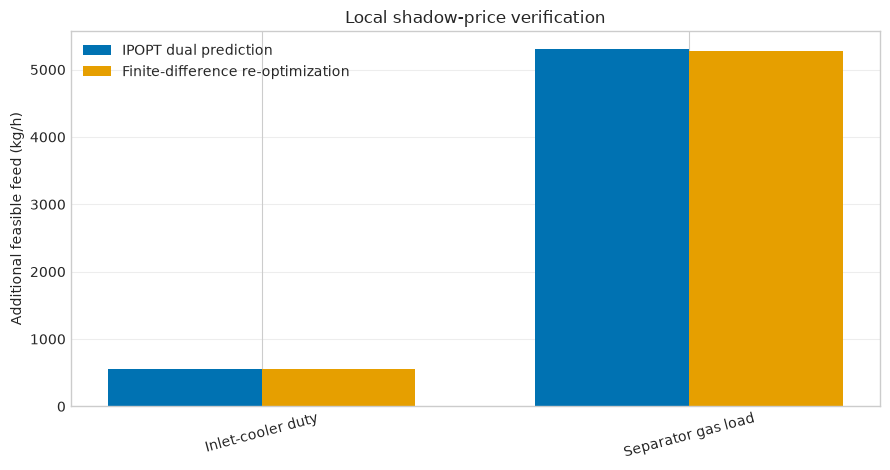

In [20]:
verified_shadow_rows = shadow_table.dropna(
    subset=["Finite-difference gain per unit"]
).copy()
verified_shadow_rows["Dual gain over verification step"] = (
    verified_shadow_rows["Local gain per physical unit"]
    * verified_shadow_rows["Verification step"]
)
verified_shadow_rows["Re-optimized gain over verification step"] = (
    verified_shadow_rows["Finite-difference gain per unit"]
    * verified_shadow_rows["Verification step"]
)

fig, axis = plt.subplots(figsize=(9, 4.8))
bar_positions = np.arange(len(verified_shadow_rows))
bar_width = 0.36
axis.bar(
    bar_positions - bar_width / 2,
    verified_shadow_rows["Dual gain over verification step"],
    width=bar_width,
    color="#0072B2",
    label="IPOPT dual prediction",
)
axis.bar(
    bar_positions + bar_width / 2,
    verified_shadow_rows[
        "Re-optimized gain over verification step"
    ],
    width=bar_width,
    color="#E69F00",
    label="Finite-difference re-optimization",
)
axis.set_xticks(
    bar_positions,
    verified_shadow_rows["Constraint"],
    rotation=15,
)
axis.set_ylabel("Additional feasible feed (kg/h)")
axis.set_title("Local shadow-price verification")
axis.legend()
axis.grid(True, axis="y", alpha=0.35)
fig.tight_layout()
plt.show()


**Figure discussion — shadow prices.** Observation: the dual and explicit relaxation
identify refrigeration and separator gas-load capacity as valuable near the IPOPT point.
Mechanism: relaxing either active margin permits a higher feed rate until another limit
takes over. Engineering implication: duals rank marginal opportunities, but a finite
upgrade can cross an active-set boundary. Recommendation: verify important shadow prices
by re-optimization and use discrete package screening for actual brownfield decisions.


## 13. Multi-objective Pareto front by epsilon constraints

Weighted sums can miss non-convex parts of a front. The epsilon-constraint method instead
sets a sequence of throughput targets and minimizes electric-equivalent power for each
target, subject to every native process limit. Because energy rises monotonically over
this range, the minimum-throughput epsilon constraint is active; it is imposed as an
equality for better numerical conditioning. The process model is still evaluated exactly
in NeqSim at every SLSQP trial.


In [21]:
maximum_verified_throughput = min(
    float(ipopt_exact_result.getObjectivesRaw()[0]),
    float(scipy_exact_result.getObjectivesRaw()[0]),
)
throughput_targets = np.linspace(
    60_000.0,
    0.995 * maximum_verified_throughput,
    9,
)

pareto_rows = []
previous_physical_point = np.array([60_000.0, 25.0, 122.0])
for throughput_target in throughput_targets:
    def target_residual(scaled_point, target=throughput_target):
        evaluation_result = evaluate_scaled(scaled_point)
        throughput = float(evaluation_result.getObjectivesRaw()[0])
        return np.array([(throughput - target) / target])

    previous_physical_point[0] = max(
        previous_physical_point[0],
        throughput_target,
    )
    clear_evaluation_cache()
    pareto_solution = solve_slsqp(
        previous_physical_point,
        objective_callback=energy_objective,
        extra_constraints=[
            {"type": "eq", "fun": target_residual},
        ],
    )
    pareto_point = to_physical(pareto_solution.x)
    pareto_result = evaluator.evaluate(pareto_point)
    pareto_objectives = np.asarray(
        pareto_result.getObjectivesRaw(),
        dtype=float,
    )
    pareto_margins = np.asarray(
        pareto_result.getConstraintMargins(),
        dtype=float,
    ) / constraint_scales
    assert pareto_solution.success
    assert pareto_margins.min() > -2.0e-4
    pareto_rows.append(
        {
            "Target throughput (kg/h)": throughput_target,
            "Achieved throughput (kg/h)": pareto_objectives[0],
            "Electric equivalent (kW)": pareto_objectives[1],
            "Cooler outlet (°C)": pareto_point[1],
            "Discharge pressure (bara)": pareto_point[2],
            "Minimum normalized margin": pareto_margins.min(),
        }
    )
    previous_physical_point = pareto_point.copy()

pareto_table = pd.DataFrame(pareto_rows)
throughput_values = pareto_table["Achieved throughput (kg/h)"].to_numpy()
energy_values = pareto_table["Electric equivalent (kW)"].to_numpy()
throughput_normalized = (
    throughput_values - throughput_values.min()
) / (throughput_values.max() - throughput_values.min())
energy_normalized = (
    energy_values - energy_values.min()
) / (energy_values.max() - energy_values.min())
distance_to_utopia = np.sqrt(
    (1.0 - throughput_normalized) ** 2 + energy_normalized ** 2
)
knee_index = int(np.argmin(distance_to_utopia))
pareto_table["Utopia distance"] = distance_to_utopia
pareto_table["Knee point"] = False
pareto_table.loc[knee_index, "Knee point"] = True
pareto_table


,Target throughput (kg/h),Achieved throughput (kg/h),Electric equivalent (kW),Cooler outlet (°C),Discharge pressure (bara),Minimum normalized margin,Utopia distance,Knee point
0,60000.000000,60000.000000,911.734283,30.000000,122.000000,0.000000e+00,1.000000,False
1,76517.823001,76517.823001,1162.732042,30.000000,122.000000,0.000000e+00,0.881180,False
2,93035.646002,93035.646002,1413.729800,30.000000,122.000000,0.000000e+00,0.778405,False
3,109553.469004,109553.469004,1664.727560,30.000000,122.000000,0.000000e+00,0.698789,False
4,126071.292005,126071.292005,1915.725318,30.000000,122.000000,0.000000e+00,0.650888,False
5,142589.115006,142589.115006,2166.723077,30.000000,122.000000,0.000000e+00,0.641843,True
6,159106.938007,159106.938007,2417.720835,30.000000,122.000000,0.000000e+00,0.673220,False
7,175624.761008,175624.761008,2668.718595,30.000000,122.000000,0.000000e+00,0.739896,False
8,192142.584010,192142.584010,3321.003464,14.214609,122.011237,8.316369e-12,1.000000,False


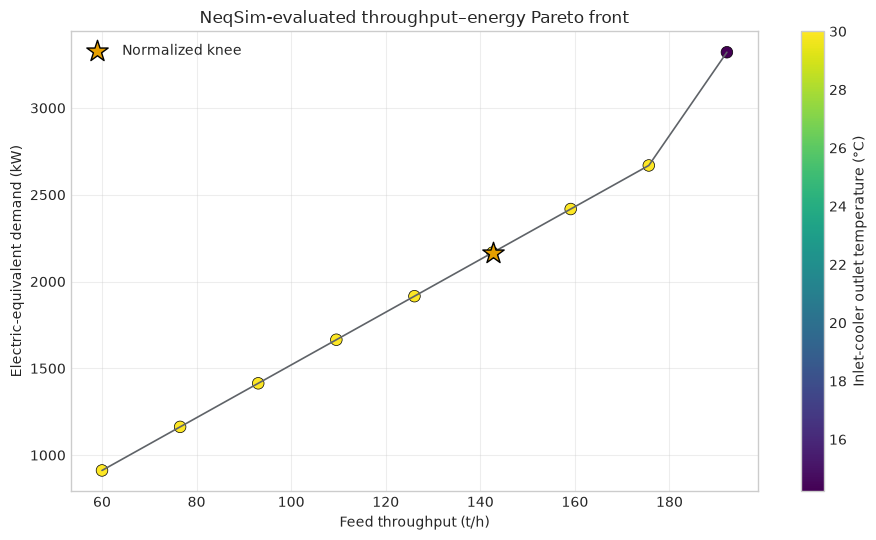

In [22]:
fig, axis = plt.subplots(figsize=(9.5, 5.5))
scatter = axis.scatter(
    throughput_values / 1_000.0,
    energy_values,
    c=pareto_table["Cooler outlet (°C)"],
    cmap="viridis",
    s=70,
    edgecolor="black",
    linewidth=0.5,
)
axis.plot(
    throughput_values / 1_000.0,
    energy_values,
    color="#5F6368",
    linewidth=1.2,
)
axis.scatter(
    throughput_values[knee_index] / 1_000.0,
    energy_values[knee_index],
    marker="*",
    s=260,
    color="#E69F00",
    edgecolor="black",
    label="Normalized knee",
    zorder=4,
)
colorbar = fig.colorbar(scatter, ax=axis)
colorbar.set_label("Inlet-cooler outlet temperature (°C)")
axis.set_xlabel("Feed throughput (t/h)")
axis.set_ylabel("Electric-equivalent demand (kW)")
axis.set_title("NeqSim-evaluated throughput–energy Pareto front")
axis.legend()
axis.grid(True, alpha=0.35)
fig.tight_layout()
plt.show()


**Figure discussion — Pareto front.** Observation: higher feed throughput requires higher
electric-equivalent demand, and the color trend shows the cooling setpoint used to manage
the phase split. Mechanism: colder operation transfers hydrocarbons to the liquid product
and changes compressor suction conditions, while refrigeration itself consumes energy.
Engineering implication: there is no single optimum until throughput and energy are valued.
Recommendation: select a point using explicit commercial or emissions weights, then rerun
the exact NeqSim model at nearby operating conditions.


## 14. Discrete brownfield upgrade choices

`ProcessSimulationEvaluator` is a continuous NLP interface, not a mixed-integer solver.
For a small brownfield option set, transparent enumeration is robust: apply one discrete
capacity package, solve the continuous operating problem inside that package, and compare
the verified results. Larger superstructures can use the same nested pattern with a MINLP
or decomposition framework.

The annual value calculation below is intentionally illustrative. It uses 8,000 operating
hours per year, a 35 EUR/t contribution margin on incremental feed, a 10-year life, and a
10% discount rate. It is a screening metric, not a project estimate.


In [23]:
upgrade_scenarios = [
    {
        "Scenario": "As-is",
        "Driver limit (kW)": 2_600.0,
        "Cooler limit (kW)": 3_500.0,
        "Gas-load limit (m/s)": 0.033,
        "CAPEX (M EUR)": 0.0,
    },
    {
        "Scenario": "Driver uprate",
        "Driver limit (kW)": 3_200.0,
        "Cooler limit (kW)": 3_500.0,
        "Gas-load limit (m/s)": 0.033,
        "CAPEX (M EUR)": 12.0,
    },
    {
        "Scenario": "Cooling augmentation",
        "Driver limit (kW)": 2_600.0,
        "Cooler limit (kW)": 5_000.0,
        "Gas-load limit (m/s)": 0.033,
        "CAPEX (M EUR)": 8.0,
    },
    {
        "Scenario": "Separator internals",
        "Driver limit (kW)": 2_600.0,
        "Cooler limit (kW)": 3_500.0,
        "Gas-load limit (m/s)": 0.040,
        "CAPEX (M EUR)": 7.0,
    },
    {
        "Scenario": "Cooling + separator",
        "Driver limit (kW)": 2_600.0,
        "Cooler limit (kW)": 5_000.0,
        "Gas-load limit (m/s)": 0.040,
        "CAPEX (M EUR)": 14.0,
    },
    {
        "Scenario": "Integrated package",
        "Driver limit (kW)": 3_200.0,
        "Cooler limit (kW)": 5_000.0,
        "Gas-load limit (m/s)": 0.040,
        "CAPEX (M EUR)": 23.0,
    },
]

driver_constraint = constraint_objects[0]
cooler_constraint = constraint_objects[2]
separator_constraint = constraint_objects[3]
base_constraint_limits = {
    "driver": driver_constraint.getUpperBound(),
    "cooler": cooler_constraint.getUpperBound(),
    "separator": separator_constraint.getUpperBound(),
}

scenario_rows = []
scenario_results = {}
for scenario in upgrade_scenarios:
    driver_constraint.setUpperBound(scenario["Driver limit (kW)"])
    cooler_constraint.setUpperBound(scenario["Cooler limit (kW)"])
    separator_constraint.setUpperBound(
        scenario["Gas-load limit (m/s)"]
    )
    candidate_solutions = []
    scenario_starts = [
        ipopt_physical_point,
        np.array([220_000.0, 10.0, 122.0]),
        np.array([180_000.0, 22.0, 125.0]),
    ]
    for scenario_start in scenario_starts:
        clear_evaluation_cache()
        candidate_solution = solve_slsqp(scenario_start)
        candidate_point = to_physical(candidate_solution.x)
        candidate_result = evaluator.evaluate(candidate_point)
        candidate_margins = np.asarray(
            candidate_result.getConstraintMargins(),
            dtype=float,
        ) / constraint_scales
        if candidate_solution.success and candidate_margins.min() > -2.0e-4:
            candidate_solutions.append(
                (candidate_solution, candidate_point, candidate_result)
            )

    if not candidate_solutions:
        raise RuntimeError(
            f"No feasible continuous solution for {scenario['Scenario']}"
        )

    best_candidate = max(
        candidate_solutions,
        key=lambda item: item[2].getObjectivesRaw()[0],
    )
    _, scenario_point, scenario_result = best_candidate
    scenario_margins = np.asarray(
        scenario_result.getConstraintMargins(),
        dtype=float,
    )
    scenario_normalized_margins = scenario_margins / constraint_scales
    binding_constraints = [
        constraint_metadata[index]["name"]
        for index, margin in enumerate(scenario_normalized_margins)
        if abs(margin) < 2.0e-3
    ]
    scenario_name = scenario["Scenario"]
    scenario_results[scenario_name] = scenario_result
    scenario_rows.append(
        {
            **scenario,
            "Feed throughput (kg/h)": (
                scenario_result.getObjectivesRaw()[0]
            ),
            "Cooler outlet (°C)": scenario_point[1],
            "Discharge pressure (bara)": scenario_point[2],
            "Electric equivalent (kW)": (
                scenario_result.getObjectivesRaw()[1]
            ),
            "Mass residual": scenario_result.getObjectivesRaw()[2],
            "Binding constraints": ", ".join(binding_constraints),
            "Minimum normalized margin": scenario_normalized_margins.min(),
        }
    )

driver_constraint.setUpperBound(base_constraint_limits["driver"])
cooler_constraint.setUpperBound(base_constraint_limits["cooler"])
separator_constraint.setUpperBound(base_constraint_limits["separator"])
clear_evaluation_cache()

upgrade_table = pd.DataFrame(scenario_rows)
as_is_throughput = float(
    upgrade_table.loc[
        upgrade_table["Scenario"] == "As-is",
        "Feed throughput (kg/h)",
    ].iloc[0]
)
upgrade_table["Incremental throughput (kg/h)"] = (
    upgrade_table["Feed throughput (kg/h)"] - as_is_throughput
)

OPERATING_HOURS_PER_YEAR = 8_000.0
CONTRIBUTION_EUR_PER_TONNE = 35.0
DISCOUNT_RATE = 0.10
ECONOMIC_LIFE_YEARS = 10
annuity_factor = (
    DISCOUNT_RATE * (1.0 + DISCOUNT_RATE) ** ECONOMIC_LIFE_YEARS
) / ((1.0 + DISCOUNT_RATE) ** ECONOMIC_LIFE_YEARS - 1.0)
upgrade_table["Gross incremental value (M EUR/y)"] = (
    upgrade_table["Incremental throughput (kg/h)"]
    / 1_000.0
    * OPERATING_HOURS_PER_YEAR
    * CONTRIBUTION_EUR_PER_TONNE
    / 1.0e6
)
upgrade_table["Annualized CAPEX (M EUR/y)"] = (
    upgrade_table["CAPEX (M EUR)"] * annuity_factor
)
upgrade_table["Illustrative net value (M EUR/y)"] = (
    upgrade_table["Gross incremental value (M EUR/y)"]
    - upgrade_table["Annualized CAPEX (M EUR/y)"]
)
recommended_upgrade = upgrade_table.sort_values(
    "Illustrative net value (M EUR/y)",
    ascending=False,
).iloc[0]

display(upgrade_table)
print(
    "Highest illustrative annual value: "
    f"{recommended_upgrade['Scenario']}"
)


Highest illustrative annual value: Integrated package


,Scenario,Driver limit (kW),Cooler limit (kW),Gas-load limit (m/s),CAPEX (M EUR),Feed throughput (kg/h),Cooler outlet (°C),Discharge pressure (bara),Electric equivalent (kW),Mass residual,Binding constraints,Minimum normalized margin,Incremental throughput (kg/h),Gross incremental value (M EUR/y),Annualized CAPEX (M EUR/y),Illustrative net value (M EUR/y)
0,As-is,2600.0,3500.0,0.033,0.0,193108.124633,13.387312,122.532712,3385.230166,1.507126e-16,"Inlet-cooler duty, Separator gas load",-9.994654e-09,0.000000,0.000000,0.000000,0.000000
1,Driver uprate,3200.0,3500.0,0.033,12.0,193108.124633,13.387312,122.532712,3385.230166,1.507126e-16,"Inlet-cooler duty, Separator gas load",-9.994654e-09,0.000000,0.000000,1.952945,-1.952945
2,Cooling augmentation,2600.0,5000.0,0.033,8.0,201388.228881,6.776506,122.224096,3693.852740,2.890321e-16,"Inlet-cooler duty, Separator gas load, Export ...",2.251494e-09,8280.104248,2.318429,1.301963,1.016466
3,Separator internals,2600.0,3500.0,0.040,7.0,200890.184986,14.088763,122.000000,3475.000000,0.000000e+00,"Driver power, Inlet-cooler duty, Export pressure",-8.318824e-09,7782.060353,2.178977,1.139218,1.039759
4,Cooling + separator,2600.0,5000.0,0.040,14.0,212544.585062,8.049331,122.000000,3850.000005,1.369305e-16,"Driver power, Inlet-cooler duty, Export pressure",-1.401234e-08,19436.460429,5.442209,2.278436,3.163773
5,Integrated package,3200.0,5000.0,0.040,23.0,238231.999211,10.544098,122.532712,4266.772352,1.221659e-16,"Inlet-cooler duty, Separator gas load",-2.223280e-08,45123.874578,12.634685,3.743144,8.891541


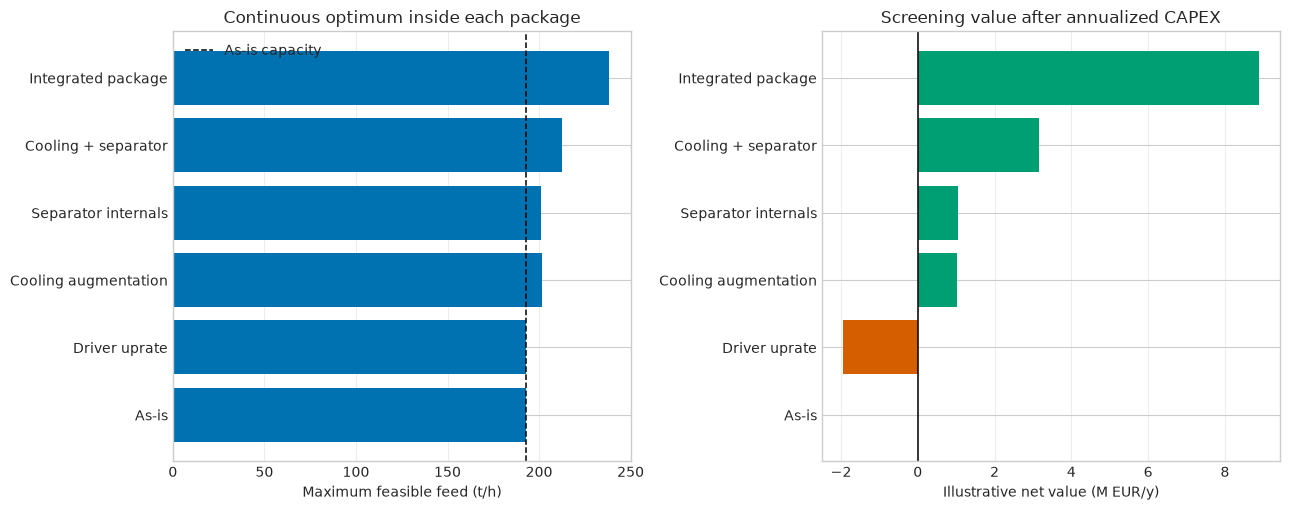

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
scenario_names = upgrade_table["Scenario"]

axes[0].barh(
    scenario_names,
    upgrade_table["Feed throughput (kg/h)"] / 1_000.0,
    color="#0072B2",
)
axes[0].axvline(
    as_is_throughput / 1_000.0,
    color="black",
    linestyle="--",
    linewidth=1.1,
    label="As-is capacity",
)
axes[0].set_xlabel("Maximum feasible feed (t/h)")
axes[0].set_title("Continuous optimum inside each package")
axes[0].legend()

net_values = upgrade_table["Illustrative net value (M EUR/y)"]
net_colors = ["#009E73" if value >= 0.0 else "#D55E00" for value in net_values]
axes[1].barh(scenario_names, net_values, color=net_colors)
axes[1].axvline(0.0, color="black", linewidth=1.1)
axes[1].set_xlabel("Illustrative net value (M EUR/y)")
axes[1].set_title("Screening value after annualized CAPEX")

for upgrade_axis in axes:
    upgrade_axis.grid(True, axis="x", alpha=0.35)

fig.tight_layout()
plt.show()


**Figure discussion — discrete upgrades.** Observation: single-equipment uprates can
deliver little production because another co-bottleneck immediately takes over, while an
integrated package can unlock a larger rate. Mechanism: the active constraint set shifts
after each discrete capacity change. Engineering implication: adding individual shadow
prices is not sufficient for finite brownfield packages. Recommendation: enumerate credible
combinations, solve the continuous operation inside each, and then replace the teaching
economics with project-controlled CAPEX, downtime, production value, and uncertainty.


## 15. Validation and nearby-point challenge

The evidence ladder used here is conservation and numerical consistency rather than an
external plant benchmark. The final checks require solver success, close SLSQP–IPOPT
throughput agreement, very small mass residuals, acceptable margin tolerances, and the
expected loss of feasibility when rate is increased just above the optimum while other
setpoints are fixed.


In [25]:
solver_throughput_difference_percent = (
    abs(
        float(scipy_exact_result.getObjectivesRaw()[0])
        - float(ipopt_exact_result.getObjectivesRaw()[0])
    )
    / float(ipopt_exact_result.getObjectivesRaw()[0])
    * 100.0
)

nearby_points = {
    "One percent lower rate": ipopt_physical_point.copy(),
    "IPOPT point": ipopt_physical_point.copy(),
    "One percent higher rate": ipopt_physical_point.copy(),
}
nearby_points["One percent lower rate"][0] *= 0.99
nearby_points["One percent higher rate"][0] *= 1.01

nearby_rows = []
for nearby_name, nearby_point in nearby_points.items():
    nearby_result = evaluator.evaluate(nearby_point)
    nearby_margins = np.asarray(
        nearby_result.getConstraintMargins(),
        dtype=float,
    ) / constraint_scales
    nearby_rows.append(
        {
            "Point": nearby_name,
            "Feed (kg/h)": nearby_result.getObjectivesRaw()[0],
            "Minimum normalized margin": nearby_margins.min(),
            "Feasible within 2e-4": nearby_margins.min() >= -2.0e-4,
            "Mass residual": nearby_result.getObjectivesRaw()[2],
        }
    )

nearby_table = pd.DataFrame(nearby_rows)
maximum_scenario_mass_residual = upgrade_table["Mass residual"].max()
scipy_minimum_margin = (
    np.asarray(
        scipy_exact_result.getConstraintMargins(),
        dtype=float,
    )
    / constraint_scales
).min()
ipopt_minimum_margin = (
    np.asarray(
        ipopt_exact_result.getConstraintMargins(),
        dtype=float,
    )
    / constraint_scales
).min()

validation_table = pd.DataFrame(
    {
        "Check": [
            "NeqSim source JAR selected",
            "All SciPy starts converged",
            "IPOPT returned success",
            "SLSQP–IPOPT throughput difference",
            "SciPy minimum normalized margin",
            "IPOPT minimum normalized margin",
            "Maximum upgrade-case mass residual",
            "Lower-rate point feasible",
            "Higher-rate point infeasible",
        ],
        "Result": [
            SOURCE_JAR.name in EVALUATOR_JAR_LOCATION,
            bool(slsqp_summary["Success"].all()),
            bool(ipopt_stats["success"]),
            solver_throughput_difference_percent,
            scipy_minimum_margin,
            ipopt_minimum_margin,
            maximum_scenario_mass_residual,
            bool(nearby_table.iloc[0]["Feasible within 2e-4"]),
            not bool(nearby_table.iloc[2]["Feasible within 2e-4"]),
        ],
        "Acceptance": [
            "True",
            "True",
            "True",
            "< 1 %",
            "> -2e-4",
            "> -2e-4",
            "< 1e-8",
            "True",
            "True",
        ],
    }
)

assert SOURCE_JAR.name in EVALUATOR_JAR_LOCATION
assert slsqp_summary["Success"].all()
assert ipopt_stats["success"]
assert solver_throughput_difference_percent < 1.0
assert scipy_minimum_margin > -2.0e-4
assert ipopt_minimum_margin > -2.0e-4
assert maximum_scenario_mass_residual < 1.0e-8
assert nearby_table.iloc[0]["Feasible within 2e-4"]
assert not nearby_table.iloc[2]["Feasible within 2e-4"]

display(validation_table)
display(nearby_table)


,Check,Result,Acceptance
0,NeqSim source JAR selected,True,True
1,All SciPy starts converged,True,True
2,IPOPT returned success,True,True
3,SLSQP–IPOPT throughput difference,0.000001,< 1 %
4,SciPy minimum normalized margin,-0.0,> -2e-4
5,IPOPT minimum normalized margin,-0.0,> -2e-4
6,Maximum upgrade-case mass residual,0.0,< 1e-8
7,Lower-rate point feasible,True,True
8,Higher-rate point infeasible,True,True


,Point,Feed (kg/h),Minimum normalized margin,Feasible within 2e-4,Mass residual
0,One percent lower rate,191177.043386,4.366492e-03,True,1.522350e-16
1,IPOPT point,193108.124633,-9.994654e-09,True,1.507126e-16
2,One percent higher rate,195039.205879,-1.000001e-02,False,0.000000e+00


## 16. Engineering interpretation

- `ProcessSimulationEvaluator` successfully provided one reusable nonlinear boundary for
  SciPy and CasADi/IPOPT, including raw objectives, constraint values, native margins,
  feasibility, penalties, gradients, and a constraint Jacobian.
- Scaling decisions to $[0,1]$ was essential. An unscaled finite-difference optimizer can
  interpret a useful mass-flow direction as numerically flat.
- Named negative margins made the infeasible 240 t/h request diagnosable; feasibility
  restoration returned a nearby operating point rather than an opaque solver failure.
- SciPy and IPOPT agreed on the capacity neighborhood to well within the validation target.
- The Pareto front made the throughput–energy trade-off explicit.
- IPOPT duals correctly identified local marginal capacity value, while discrete package
  enumeration exposed co-bottleneck and active-set changes.

## Limitations

1. The fluid, equipment sizes, limits, and economics are synthetic.
2. The compressor uses fixed polytropic efficiency rather than vendor speed, head,
   efficiency, surge, stonewall, driver, and anti-surge maps.
3. The separator constraint is a teaching gas-load limit, not a complete mechanical design.
4. The cooler duty and COP are simplified; no utility-network or ambient constraint is used.
5. SLSQP and IPOPT are local solvers. Multistart improves evidence but does not prove a
   global optimum.
6. CasADi finite-differences the Java callback; it does not algorithmically differentiate
   NeqSim thermodynamics.
7. Shadow prices are local and must not be used as project value without finite-step
   confirmation and controlled economics.
8. Discrete choices are enumerated. This is appropriate for a short brownfield list but is
   not a general MINLP implementation.

No actionable NeqSim defect was found while executing this notebook against the recorded
`master` commit. The external evaluator, cloning, objectives, constraints, margins,
gradients, Jacobian, SciPy adapter, and CasADi callback all behaved consistently with their
documented contracts.


## 17. Suggested exercises

1. Replace fixed efficiency with a compressor map and add surge and stonewall margins.
2. Add a second compression stage and optimize intermediate pressure.
3. Replace the teaching separator limit with a mechanical-design capacity calculation.
4. Add a gas-quality constraint such as hydrocarbon dew point or cricondenbar.
5. Compare SLSQP and IPOPT with a derivative-free global search before local refinement.
6. Build a Pyomo adapter using the same evaluator and compare finite-difference behavior.
7. Add uncertainty scenarios for feed composition, ambient temperature, and driver derate.
8. Expand discrete enumeration to include downtime and schedule interactions.

## References

- NeqSim source: [`ProcessSimulationEvaluator.java`](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/util/optimizer/ProcessSimulationEvaluator.java).
- SciPy: [`minimize(method="SLSQP")`](https://docs.scipy.org/doc/scipy/reference/optimize.minimize-slsqp.html).
- CasADi: [official documentation, Callback and NLP sections](https://web.casadi.org/docs/).
- IPOPT: [official nonlinear-program and solver documentation](https://coin-or.github.io/Ipopt/).
- Wächter, A. and Biegler, L. T. (2006), *On the implementation of an interior-point filter line-search algorithm for large-scale nonlinear programming*, Mathematical Programming 106, 25–57.
- Andersson, J. A. E., Gillis, J., Horn, G., Rawlings, J. B., and Diehl, M. (2019), *CasADi: a software framework for nonlinear optimization and optimal control*, Mathematical Programming Computation 11, 1–36.
